In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Professional Theme
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Professional Color Palette
sns.set_palette("Set2")

In [7]:
df = pd.read_csv("../data/cleaned/SampleSuperstore_Feature_Engineered.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%),Average Selling Price,Discount Percentage
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,130.98,0.0
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,243.98,0.0
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,7.31,0.0
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,191.52,45.0
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,11.18,20.0


In [8]:
df.shape

(9977, 16)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ship Mode              9977 non-null   str    
 1   Segment                9977 non-null   str    
 2   Country                9977 non-null   str    
 3   City                   9977 non-null   str    
 4   State                  9977 non-null   str    
 5   Postal Code            9977 non-null   int64  
 6   Region                 9977 non-null   str    
 7   Category               9977 non-null   str    
 8   Sub-Category           9977 non-null   str    
 9   Sales                  9977 non-null   float64
 10  Quantity               9977 non-null   int64  
 11  Discount               9977 non-null   float64
 12  Profit                 9977 non-null   float64
 13  Profit Margin (%)      9977 non-null   float64
 14  Average Selling Price  9977 non-null   float64
 15  Discount Percen

In [10]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin (%),Average Selling Price,Discount Percentage
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000,9977.000000,9977.000000,9977.000000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013,12.011351,60.985341,15.627844
std,32058.266816,623.721409,2.226657,0.206455,234.45784,46.663770,143.029841,20.645520
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800,-275.000000,0.340000,0.000000
25%,23223.000000,17.300000,2.000000,0.000000,1.72620,7.500000,5.470000,0.000000
50%,55901.000000,54.816000,3.000000,0.200000,8.67100,27.000000,16.270000,20.000000
75%,90008.000000,209.970000,5.000000,0.200000,29.37200,36.250000,63.940000,20.000000
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600,50.000000,3773.080000,80.000000


# Which product category generates the highest sales, and how can we present this information in a professional business report?

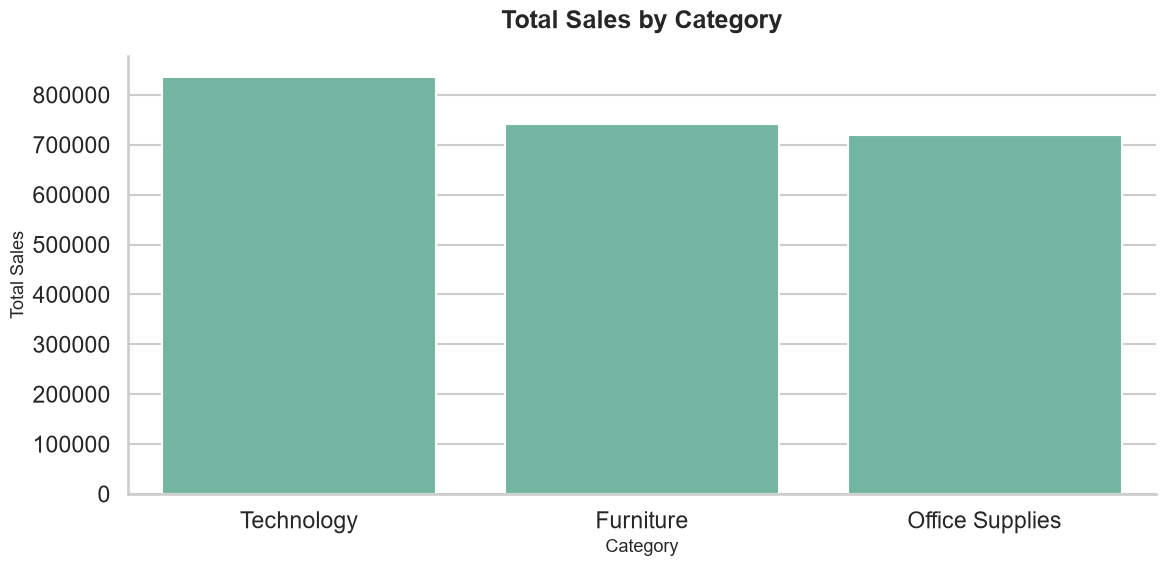

In [11]:
# Total Sales by Category
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

# Create Figure
plt.figure(figsize=(12,6))

# Create Bar Chart
ax = sns.barplot(
    x=sales_category.index,
    y=sales_category.values
)

# Title
plt.title(
    "Total Sales by Category",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Axis Labels
plt.xlabel("Category", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

# Remove Top and Right Border
sns.despine()

# Adjust Layout
plt.tight_layout()

# Display Graph
plt.show()

In [12]:
def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

# Can we display the exact sales value on each bar so that managers don't have to estimate it from the axis?


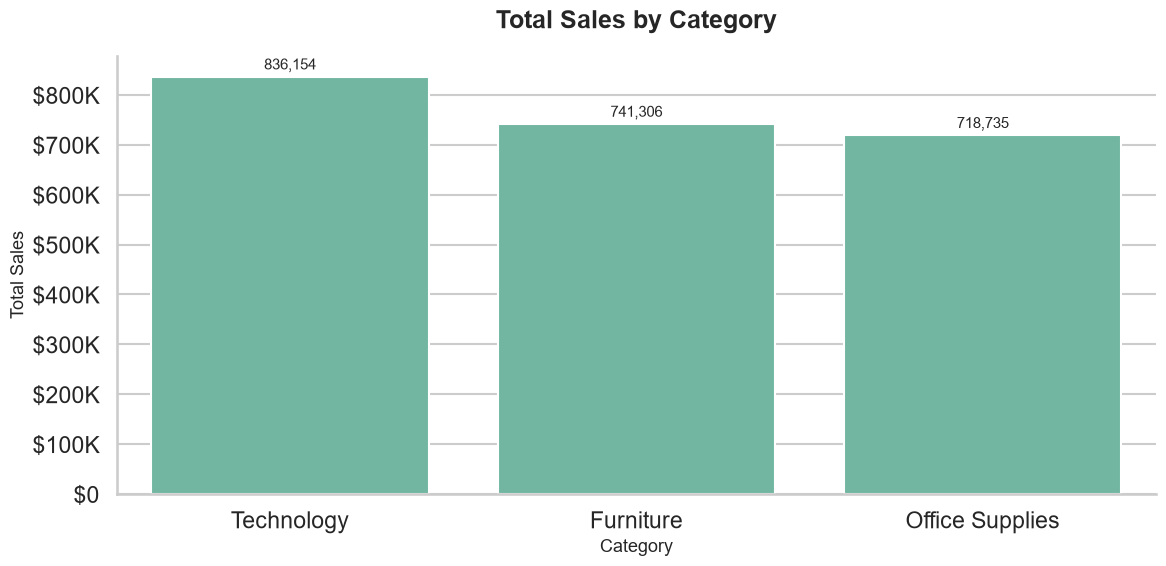

In [26]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=sales_category.index,
    y=sales_category.values
)

# Add value labels
for i in ax.containers:
    ax.bar_label(
        i,
        fmt='{:,.0f}',
        fontsize=11,
        padding=3
    )
ax.yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)
plt.title(
    "Total Sales by Category",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Category", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
def style_chart(title, xlabel, ylabel):
    plt.title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.xlabel(
        xlabel,
        fontsize=13
    )

    plt.ylabel(
        ylabel,
        fontsize=13
    )

    sns.despine()

    plt.tight_layout()

In [15]:
def format_currency_axis(ax):
    ax.yaxis.set_major_formatter(
        FuncFormatter(currency_formatter)
    )

In [16]:
def add_value_labels(ax):
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='{:,.0f}',
            fontsize=11,
            padding=3
        )

# Which product category generates the highest total sales, and how can we highlight the top-performing category in a professional business dashboard for quick decision-making?

C:\Users\Nimish patel\AppData\Local\Temp\ipykernel_5044\3810055744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


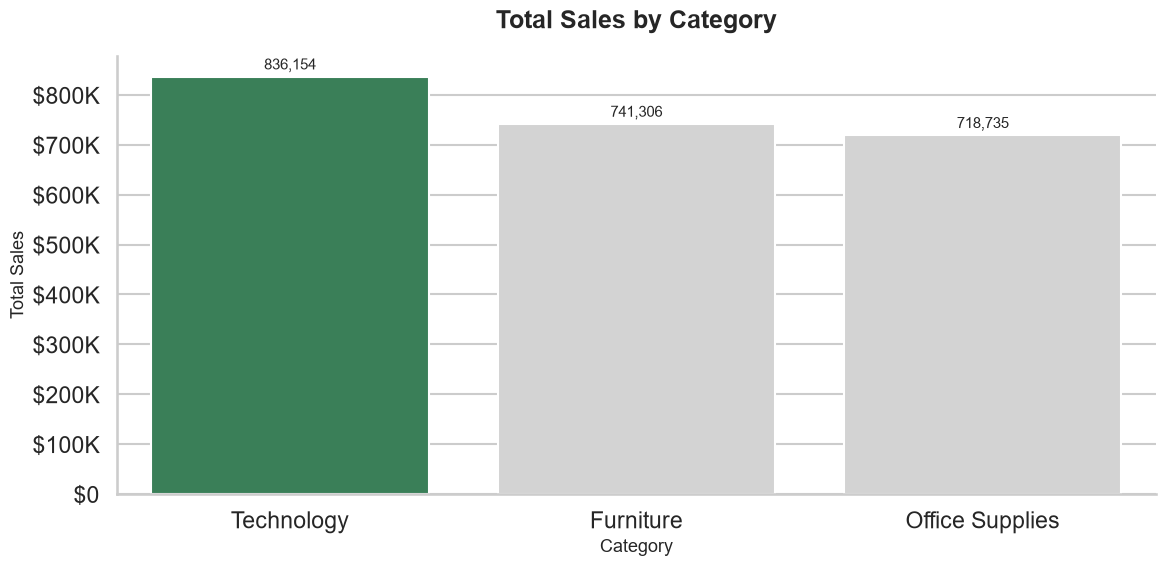

In [17]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

# Highlight Highest Category
colors = ["#D3D3D3"] * len(sales_category)
colors[0] = "#2E8B57"

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=sales_category.index,
    y=sales_category.values,
    palette=colors
)

add_value_labels(ax)

format_currency_axis(ax)

style_chart(
    "Total Sales by Category",
    "Category",
    "Total Sales"
)

plt.show()

# How do Sales and Profit compare across different product categories?

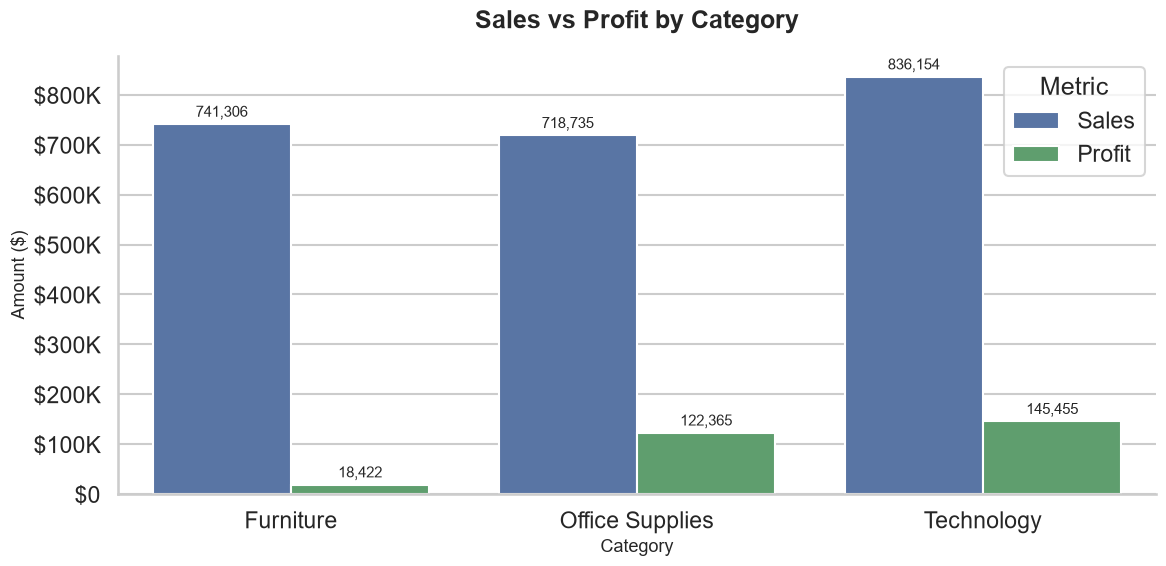

In [27]:
# Prepare Summary Data
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .reset_index()
)

# Convert data into long format
category_long = category_summary.melt(
    id_vars="Category",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Value"
)

# Create Figure
plt.figure(figsize=(12,6))

# Grouped Bar Chart
ax = sns.barplot(
    data=category_long,
    x="Category",
    y="Value",
    hue="Metric",
    palette=["#4C72B0", "#55A868"]
)

# Format Y-axis
format_currency_axis(ax)

# Add Value Labels
add_value_labels(ax)

# Apply Professional Styling
style_chart(
    "Sales vs Profit by Category",
    "Category",
    "Amount ($)"
)

# Legend Title
plt.legend(title="Metric")

plt.savefig(
    "../images/sales_vs_profit_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# How can we compare Sales and Profit together while keeping both metrics easy to understand in a single professional visualization?

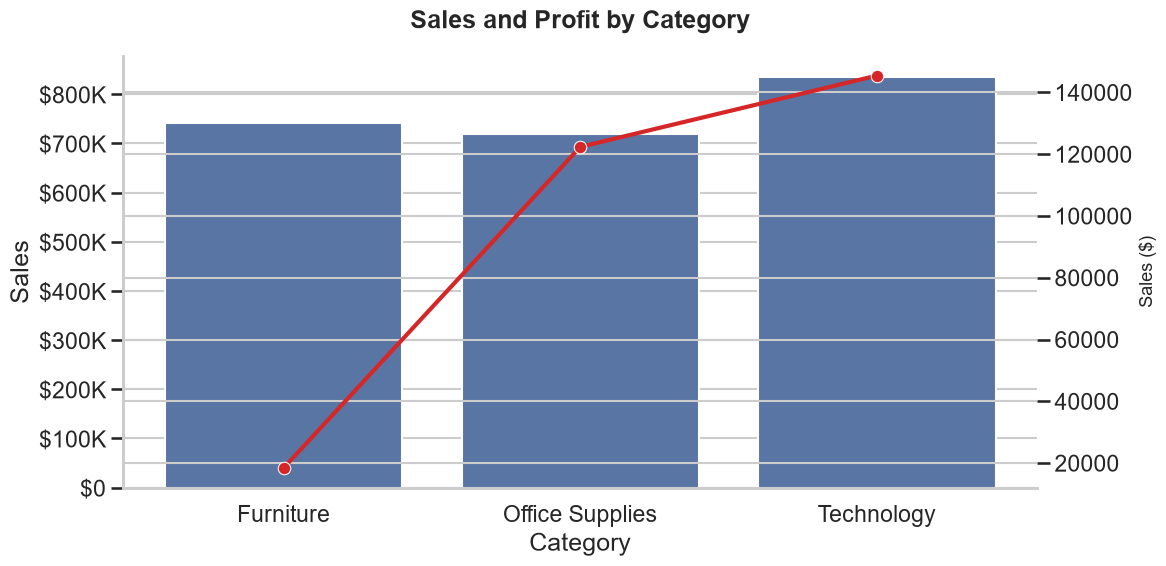

In [20]:
# Prepare Summary Data
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .reset_index()
)

# Create Figure
fig, ax1 = plt.subplots(figsize=(12,6))

# Sales Bars
sns.barplot(
    data=category_summary,
    x="Category",
    y="Sales",
    color="#4C72B0",
    ax=ax1
)

# Format Sales Axis
format_currency_axis(ax1)

# Create Second Axis
ax2 = ax1.twinx()

# Profit Line
sns.lineplot(
    data=category_summary,
    x="Category",
    y="Profit",
    marker="o",
    linewidth=3,
    color="#D62728",
    ax=ax2
)

# Profit Axis Label
ax2.set_ylabel("Profit ($)", fontsize=13)

# Title
style_chart(
    "Sales and Profit by Category",
    "Category",
    "Sales ($)"
)

plt.show()

# Can we present multiple business insights on a single dashboard so that management can quickly understand the company's performance?

C:\Users\Nimish patel\AppData\Local\Temp\ipykernel_5044\2341543534.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Nimish patel\AppData\Local\Temp\ipykernel_5044\2341543534.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Nimish patel\AppData\Local\Temp\ipykernel_5044\2341543534.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


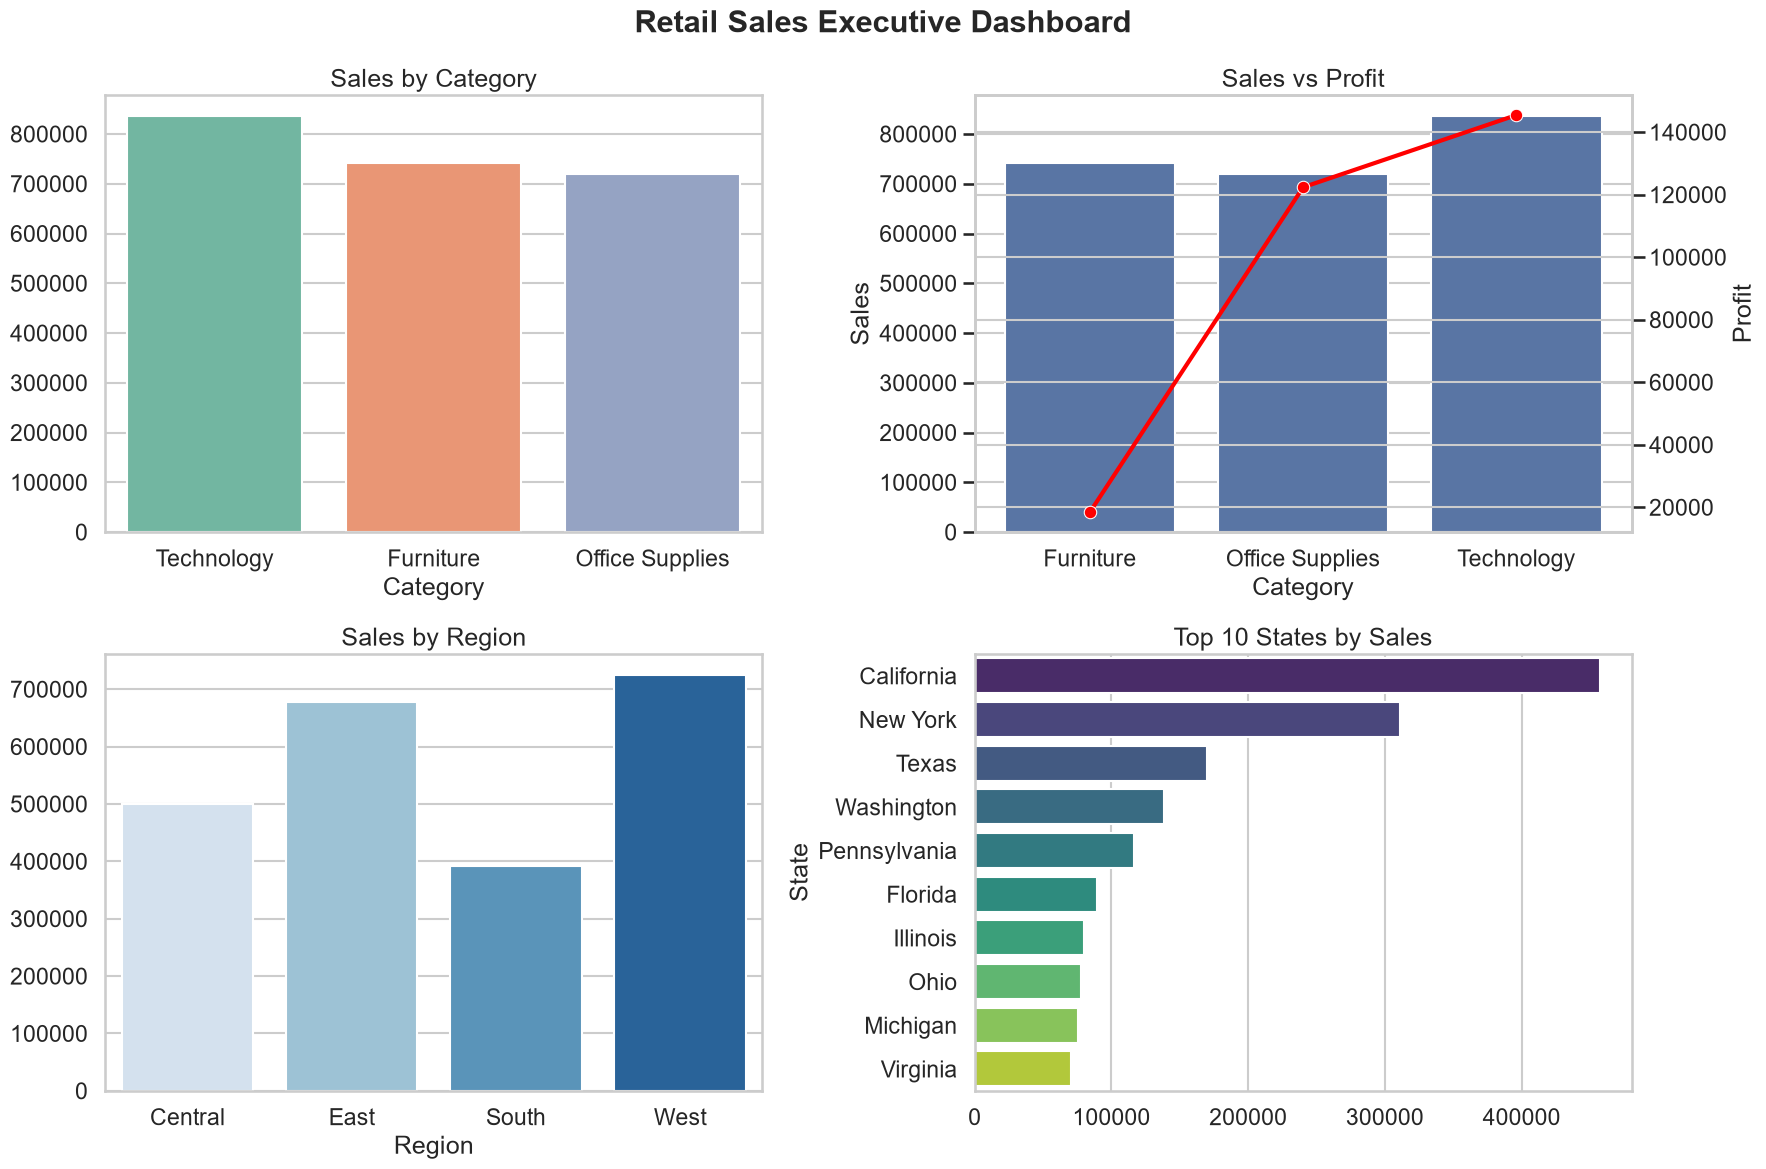

In [25]:
# Create Dashboard Canvas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -----------------------------
# Chart 1 : Sales by Category
# -----------------------------
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sns.barplot(
    x=sales_category.index,
    y=sales_category.values,
    ax=axes[0,0],
    palette="Set2"
)

axes[0,0].set_title("Sales by Category")

# -----------------------------
# Chart 2 : Sales by Region
# -----------------------------
sales_region = (
    df.groupby("Region")["Sales"]
      .sum()
)

sns.barplot(
    x=sales_region.index,
    y=sales_region.values,
    ax=axes[1,0],
    palette="Blues"
)

axes[1,0].set_title("Sales by Region")

# -----------------------------
# Chart 3 : Sales vs Profit
# -----------------------------
summary = (
    df.groupby("Category")[["Sales","Profit"]]
      .sum()
      .reset_index()
)

sns.barplot(
    data=summary,
    x="Category",
    y="Sales",
    color="#4C72B0",
    ax=axes[0,1]
)

# -----------------------------
# Profit Line
# -----------------------------
ax2 = axes[0,1].twinx()

sns.lineplot(
    data=summary,
    x="Category",
    y="Profit",
    marker="o",
    color="red",
    linewidth=3,
    ax=ax2
)

axes[0,1].set_title("Sales vs Profit")

# -----------------------------
# Chart 4 : Top States
# -----------------------------
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    y=top_states.index,
    x=top_states.values,
    ax=axes[1,1],
    palette="viridis"
)

axes[1,1].set_title("Top 10 States by Sales")

# Dashboard Title
plt.suptitle(
    "Retail Sales Executive Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/executive_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()